In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.dates import DateFormatter
import os
import scipy
import matplotlib.cm as cm
from datetime import datetime
import seaborn as sns
import pytz
import matplotlib
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from sklearn import metrics
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error

Before loading in the conductivity data, ensure you have calculated the proper datetime based off of the time the C3PO was plugged into power, which was recorded in Notes.txt. Ensure to save these datetimes as a column. It is easy to do in excel, and you can use previous calibration csvs for an example. 

You'll also need to create a "step_pts_interp.csv" file in the working folder that "fills in" points from every step change from the step_pts.txt file for every 20 seconds. Again, use previous spreadsheets as an example if needed. 

Check your conductivity data beforehand and remove points that were taken while moving the probe from one solution to the other if needed (often appears as 0 or an erroneous value when you know the sensor was coming in or out of the solution at that time). 

In [30]:
# USER INPUT 
filename = 'conductivity' #data from the calibration 
device = 'C3PO_5' 
folder = '2026_07_22_ReCalibration'

filepath = os.path.join(device, folder, filename+'.csv') 
cond = pd.read_csv(filepath, header = 0, parse_dates =[7], date_format='%yyyy-%m-%d %HH:%MM:%SS') 
cond.head()
#cond.tail()

,Real_Time,Temp_C,Cond_uScm-1,CellVoltage,StateofCharge,ErrorCode,Elapsed_sec,datetime
0,946684805,22.82,0,0.54,95.76,0,0,2026-07-22 14:09:16
1,946684823,23.12,0,0.05,94.34,0,18,2026-07-22 14:09:34
2,946684843,23.12,0,0.04,92.91,0,38,2026-07-22 14:09:54
3,946684863,23.11,0,0.04,91.49,0,58,2026-07-22 14:10:14
4,946684882,23.11,0,0.04,90.07,0,77,2026-07-22 14:10:33


In [31]:
filename = 'step_pts' #data from the calibration 
filepath = os.path.join(device, folder, filename+'.txt') 
steps = pd.read_csv(filepath, header = 0, parse_dates =['datetime'], date_format='%yyyy-%m-%d %HH:%MM:%SS') 
steps.tail()

,cond_uscm,datetime
1,0,2026-7-22 14:15:45
2,12880,2026-7-22 14:16:45
3,12880,2026-7-22 14:21:45
4,80000,2026-7-22 14:23:21
5,80000,2026-7-22 14:28:45


Previous calibration values: 
| C3PO_ID | Date of Calibration # 1 |  Slope |  intercept | 
| :---    |    :---                 |  :---  | :---       | 
|  C3PO_1 | 2025-04-23              | 0.80    |  261.99     | 
|  C3PO_2 | 2025-12-22              | 0.89    | -51.14      | 
|  C3PO_3 | 2025-12-22              | 1.05    | -848.78     | 
|  C3PO_4 | 2025-12-22              | 1.06    | -852.69     | 
|  C3PO_5 | 2025-12-22              | 0.85    | -189.80     | 
|  C3PO_6 | 2026-07-22              | 1.03    | -668.01     | 

In [9]:
# Only run this block if there are previous calibration curves you are trying to compare to 

cond['Cond_uScm-1_cal'] = cond['Cond_uScm-1']*0.89 - 51.14 #slope and intercept from the above table

In [32]:
cond['datetime'] = pd.to_datetime(cond['datetime'])
steps['datetime']= pd.to_datetime(steps['datetime'])


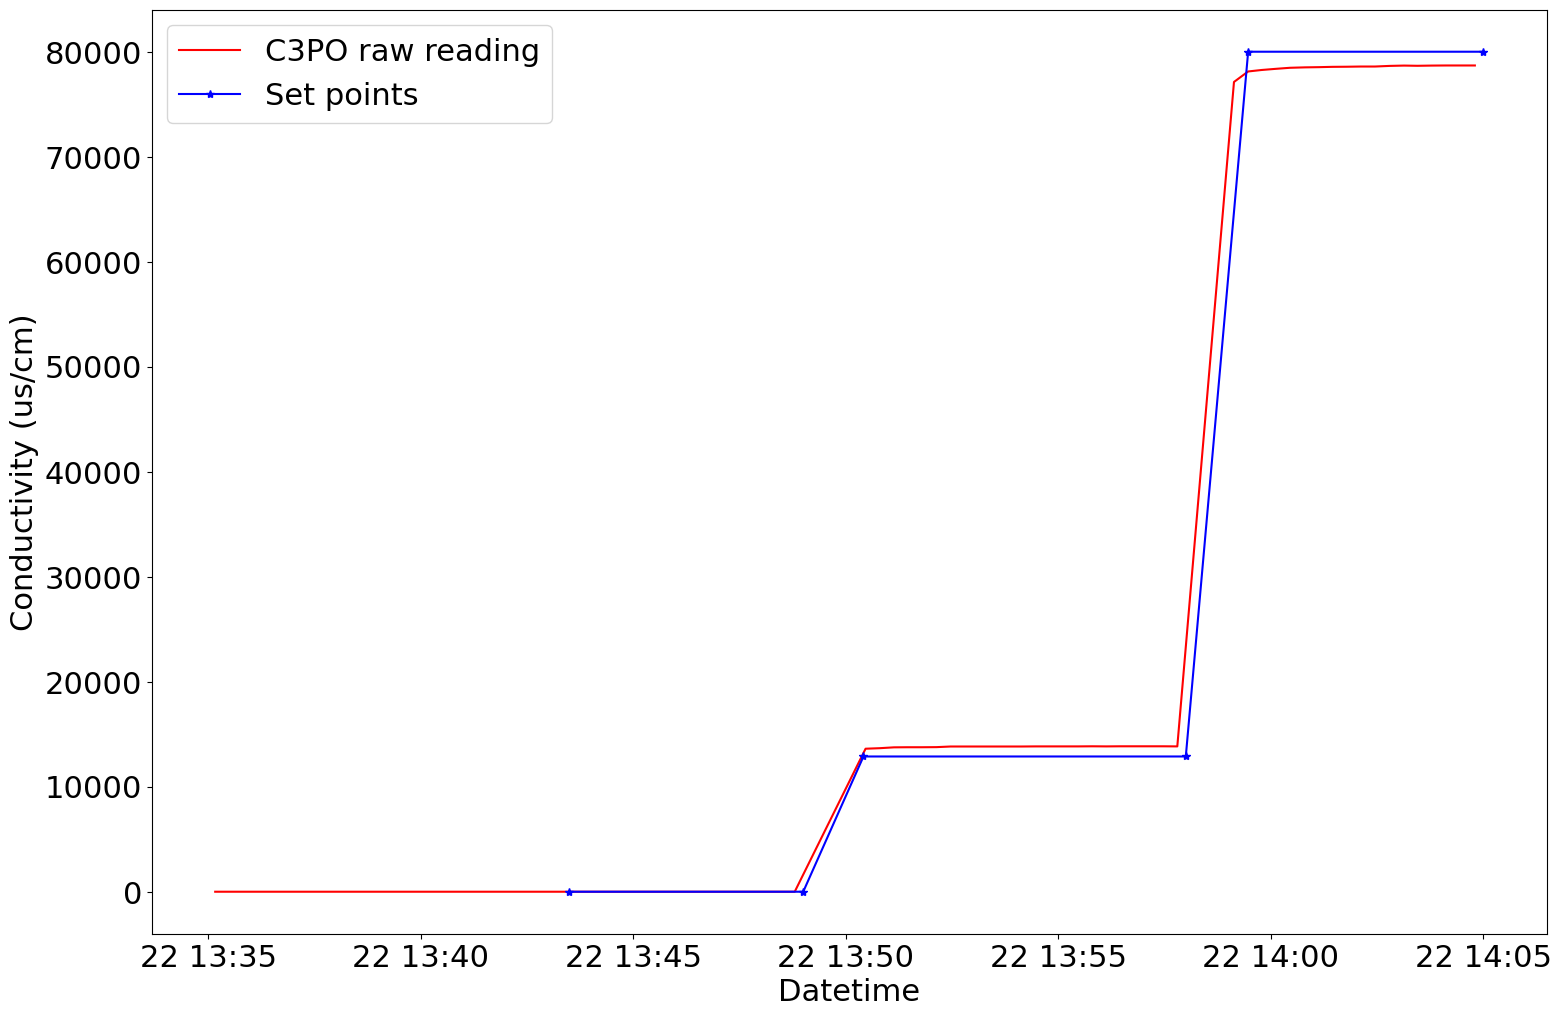

In [54]:
#Plot raw points 
plt.rcParams.update({'font.size': 22})
fig, axs = plt.subplots(figsize = (18, 12))

axs.plot(cond["datetime"], cond["Cond_uScm-1"], label = "C3PO raw reading", color = "red")
#axs.plot(cond["datetime"], cond["Cond_uScm-1_cal"], label = "Calibrated from 12-22-2025 regression", color = "green")
axs.plot(steps["datetime"], steps["cond_uscm"], label = "Set points", marker = '*', color = "blue")
axs.set_ylabel('Conductivity (us/cm)')
axs.set_xlabel('Datetime')

plt.legend()

fig_fn = 'RawReadings'
fig_file = os.path.join(device, folder, 'Figures', device+fig_fn+'.png')
plt.savefig(fig_file, dpi = 200, transparent=False)

In [33]:
filename = 'step_pts_interp' 
filepath = os.path.join(device, folder, filename+'.csv') 
steps2 = pd.read_csv(filepath, header = 0, parse_dates =['datetime'], date_format='%yyyy-%m-%d %HH:%MM:%SS') 
steps2['datetime']= pd.to_datetime(steps2['datetime'])
steps2.head()

,cond_uscm,datetime
0,0,2026-07-22 14:10:25
1,0,2026-07-22 14:10:45
2,0,2026-07-22 14:11:05
3,0,2026-07-22 14:11:25
4,0,2026-07-22 14:11:45


In [34]:
merged = pd.merge_asof(steps2, cond, on='datetime', direction='nearest')
filepath = os.path.join(device, folder, 'merged.csv') 
merged.to_csv(filepath, index=False)
print(merged)

    cond_uscm            datetime  Real_Time  Temp_C  Cond_uScm-1  \
0           0 2026-07-22 14:10:25  946684882   23.11            0   
1           0 2026-07-22 14:10:45  946684902   23.24            0   
2           0 2026-07-22 14:11:05  946684923   23.23            0   
3           0 2026-07-22 14:11:25  946684943   23.18            0   
4           0 2026-07-22 14:11:45  946684963   23.32            0   
5           0 2026-07-22 14:12:05  946684982   23.39            0   
6           0 2026-07-22 14:12:25  946685002   23.40            0   
7           0 2026-07-22 14:12:45  946685023   23.33            0   
8           0 2026-07-22 14:13:05  946685043   23.18            0   
9           0 2026-07-22 14:13:25  946685063   23.35            0   
10          0 2026-07-22 14:13:45  946685082   23.23            0   
11          0 2026-07-22 14:14:05  946685102   23.23            0   
12          0 2026-07-22 14:14:25  946685123   23.39            0   
13          0 2026-07-22 14:14:45 

In [35]:
filename = 'merged' 
filepath = os.path.join(device, folder, filename+'.csv') 
mergedcleaned = pd.read_csv(filepath, header = 0, parse_dates =['datetime'], date_format='%yyyy-%m-%d %HH:%MM:%SS') 
mergedcleaned['datetime']= pd.to_datetime(mergedcleaned['datetime'])
mergedcleaned.head()

,cond_uscm,datetime,Real_Time,Temp_C,Cond_uScm-1,CellVoltage,StateofCharge,ErrorCode,Elapsed_sec
0,0,2026-07-22 14:10:25,946684882,23.11,0,0.04,90.07,0,77
1,0,2026-07-22 14:10:45,946684902,23.24,0,0.04,88.50,0,97
2,0,2026-07-22 14:11:05,946684923,23.23,0,0.04,87.06,0,118
3,0,2026-07-22 14:11:25,946684943,23.18,0,0.04,85.63,0,138
4,0,2026-07-22 14:11:45,946684963,23.32,0,0.04,84.17,0,158


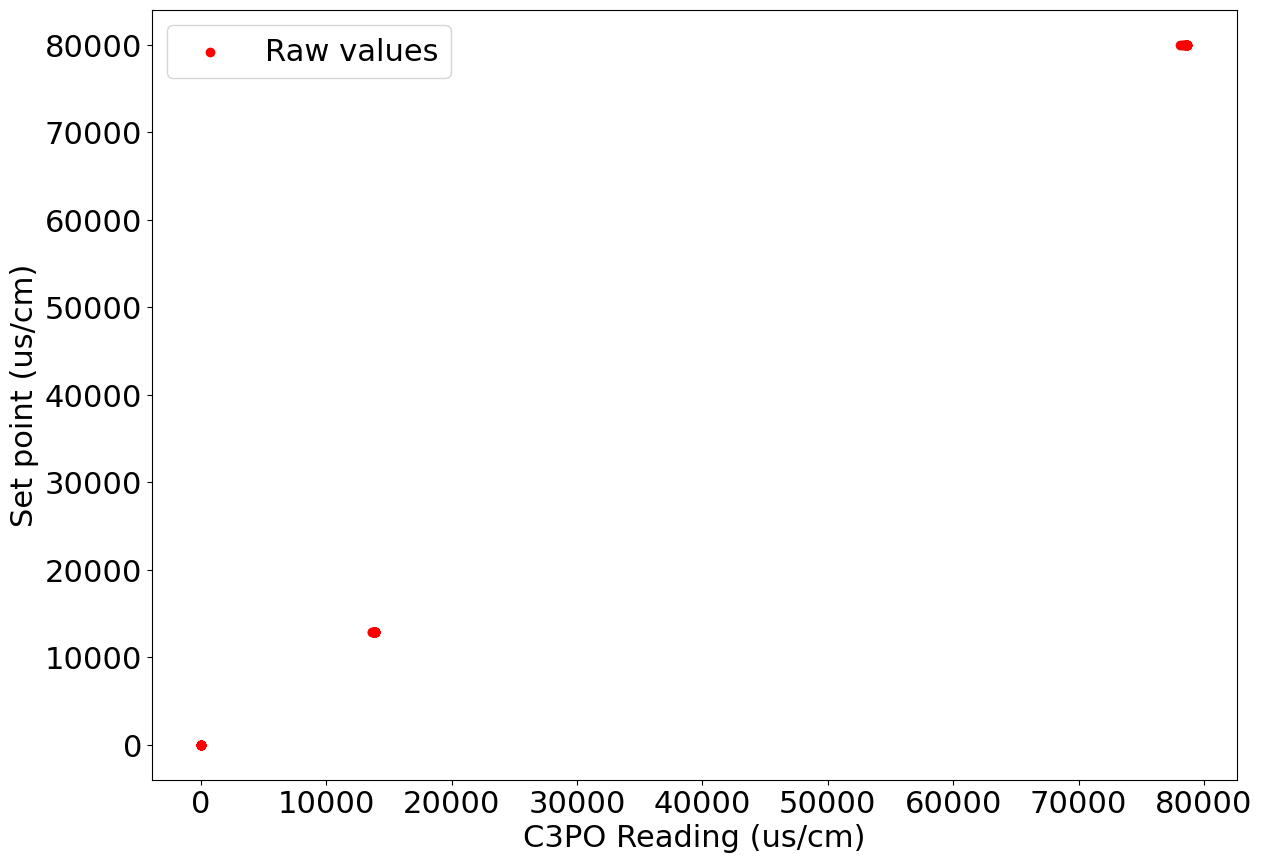

In [58]:
plt.rcParams.update({'font.size': 22})
fig, axs = plt.subplots(figsize = (14, 10))

axs.scatter(mergedcleaned["Cond_uScm-1"], mergedcleaned["cond_uscm"], label = "Raw values", color = "red")
#axs.scatter(mergedcleaned["Cond_uScm-1_cal"], mergedcleaned["cond_uscm"], label = "Calibrated from 12-22-2025 regression", color = "blue")
axs.set_ylabel('Set point (us/cm)')
axs.set_xlabel('C3PO Reading (us/cm)')

plt.legend()

fig_fn = 'versusSetPoint'
fig_file = os.path.join(device, folder, 'Figures', device+fig_fn+'.png')
plt.savefig(fig_file, dpi = 200, transparent=False)

In [36]:
y = mergedcleaned["cond_uscm"]
#x = mergedcleaned["Cond_uScm-1_cal"] #or just mergedcleaned["Cond_uScm-1"] if you aren't using a previous calibration
x = mergedcleaned["Cond_uScm-1"] 
coef = np.polyfit(x,y,1)
print(coef)
poly1d_fn = np.poly1d(coef) 
y_predicted = poly1d_fn(x)
r_squared = r2_score(y, y_predicted)
print(f"R² Value: {r_squared:.4f}")

rmse = root_mean_squared_error(y, y_predicted)
print(f"RMSE: {rmse}")


[  0.75519389 -86.50725248]
R² Value: 0.9999
RMSE: 279.6158383010573


In [43]:
rmse_test = root_mean_squared_error(y, x) #where x is the data that has already had calibration curve #1 applied to it 
print(f"RMSE: {rmse_test}")

RMSE: 5822.5987342900025


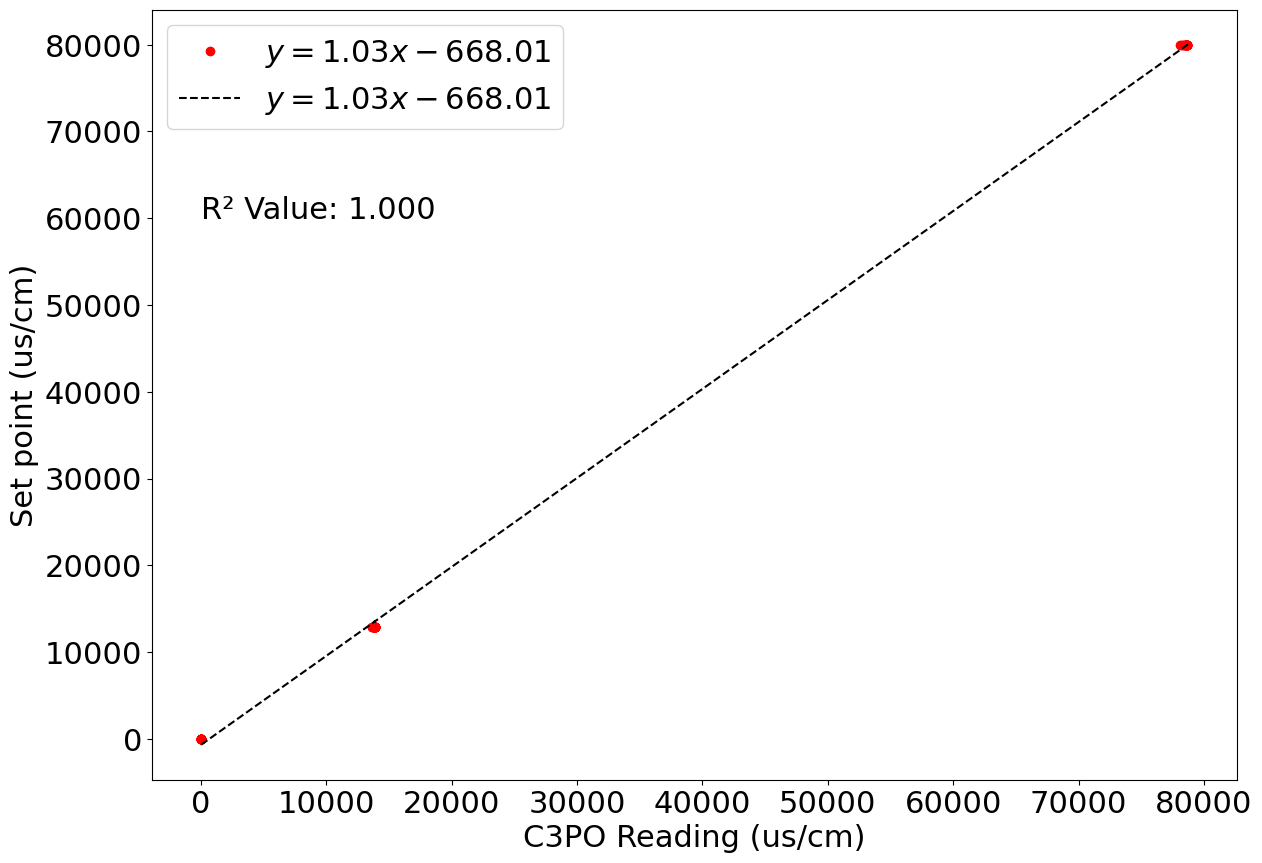

In [60]:
plt.rcParams.update({'font.size': 22})
fig, axs = plt.subplots(figsize = (14, 10))

m = coef[0]
b = coef[1]

axs.set_ylabel('Set point (us/cm)')
axs.set_xlabel('C3PO Reading (us/cm)')
axs.plot(x,y, 'ro', x, poly1d_fn(x), '--k', label=f'$y = {m:.2f}x {b:+.2f}$') 

plt.legend()
plt.text(0, 60000, f"R² Value: {r_squared:.3f}")


fig_fn = 'vsSetPoint_withRegression'
fig_file = os.path.join(device, folder, 'Figures', device+fig_fn+'.png')
plt.savefig(fig_file, dpi = 200, transparent=False)

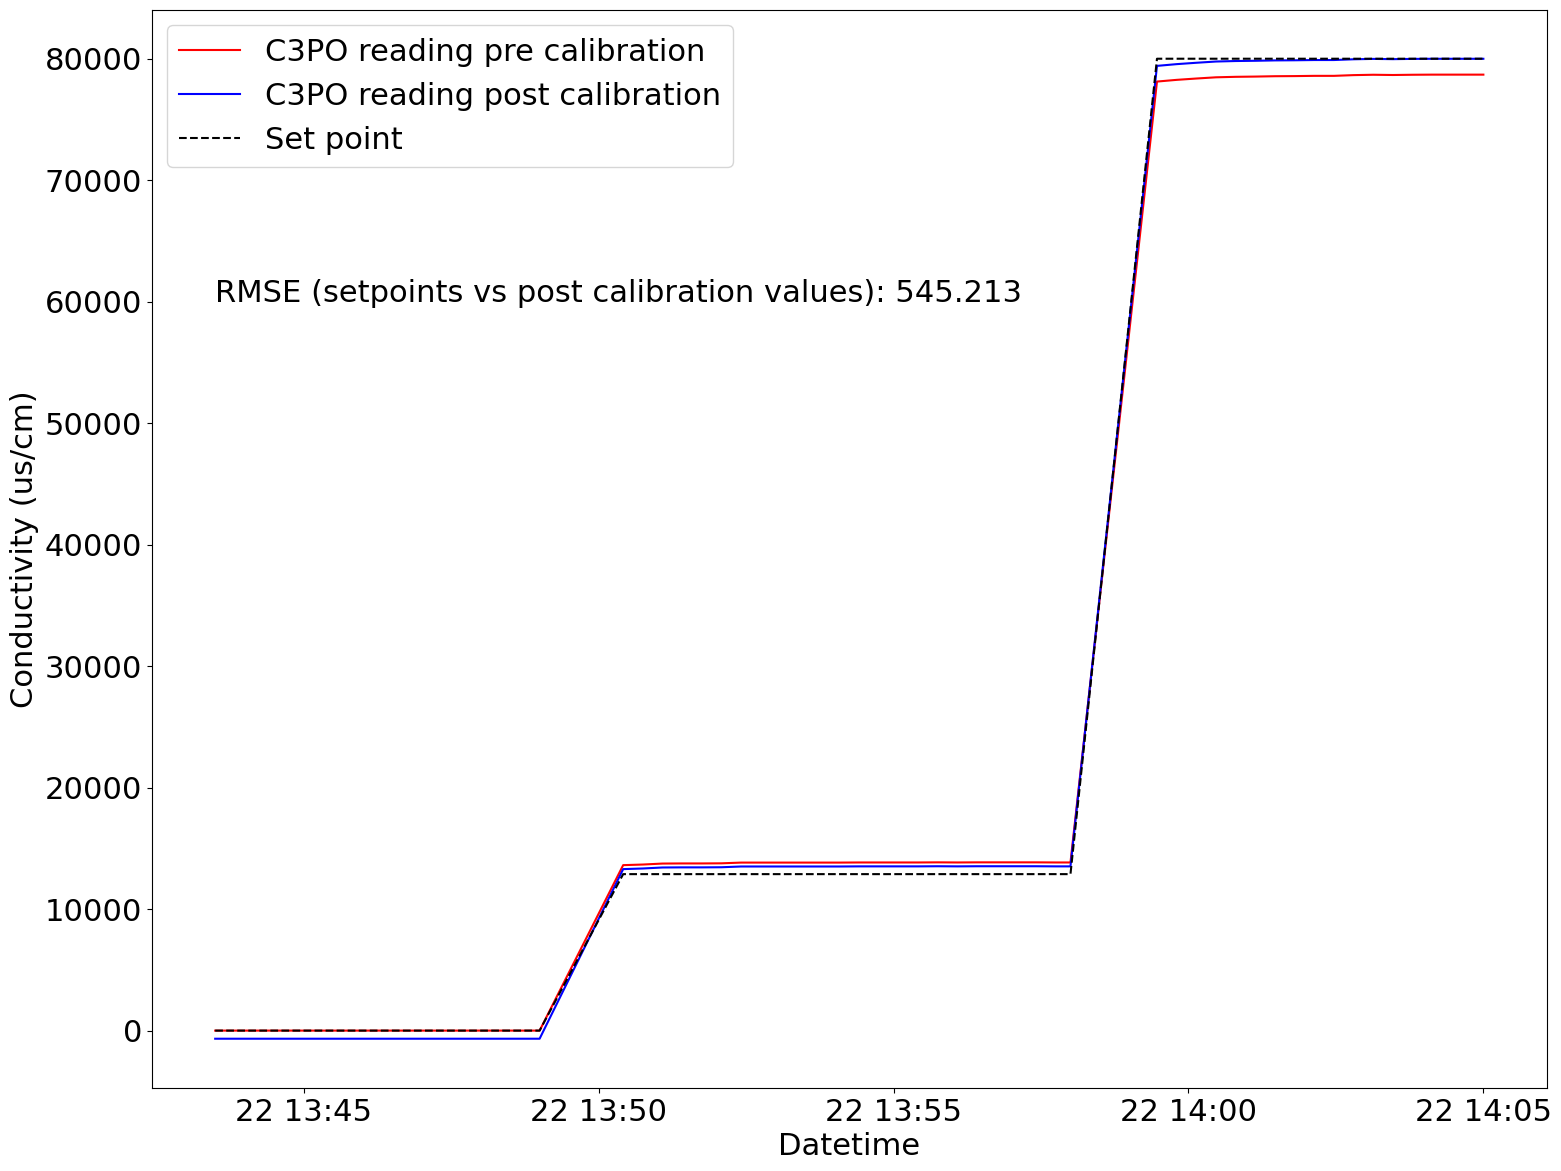

In [61]:
plt.rcParams.update({'font.size': 22})
fig, axs = plt.subplots(figsize = (18, 14))

axs.plot(mergedcleaned["datetime"], mergedcleaned["Cond_uScm-1"], label = "C3PO reading pre calibration", color = "red")
axs.plot(mergedcleaned["datetime"], m*mergedcleaned["Cond_uScm-1"] + b, label = "C3PO reading post calibration", color = "blue")
axs.plot(mergedcleaned["datetime"], mergedcleaned["cond_uscm"] , label = "Set point", linestyle = '--', color = 'black')
axs.set_ylabel('Conductivity (us/cm)')
axs.set_xlabel('Datetime')
start = mergedcleaned["datetime"].iloc[0]
plt.text(start, 60000, f"RMSE (setpoints vs post calibration values): {rmse:.3f}")
plt.legend()


fig_fn = 'PreandPostCalibration'
fig_file = os.path.join(device, folder, 'Figures', device+fig_fn+'.png')
plt.savefig(fig_file, dpi = 200, transparent=False)